数据形状: (21665, 27)

读取 feature_selection.json
原始特征数: 24
筛选后特征数: 15
删除特征数: 9
删除的特征: ['D_C', 'D_M1', 'D_M2', 'Del', 'EN', 'H_A', 'N_Ti1', 'Rad', 'SC_b']

使用特征数: 15
目标变量: Q_M
结构数量: 95
原子数量: 21665
外层折数: 5，内层折数: 5，随机种子: 42

总结构数: 95
  2x3: 19 个结构
  3x4: 19 个结构
  3x5: 19 个结构
  4x6: 19 个结构
  4x7: 19 个结构

外层折叠 1: 训练 76 结构 / 17494 原子，测试 19 结构 / 4171 原子
  训练超胞分布: {'2x3': 15, '3x4': 15, '3x5': 15, '4x6': 15, '4x7': 16}
  测试超胞分布: {'2x3': 4, '3x4': 4, '3x5': 4, '4x6': 4, '4x7': 3}

外层折叠 2: 训练 76 结构 / 17413 原子，测试 19 结构 / 4252 原子
  训练超胞分布: {'2x3': 15, '3x4': 15, '3x5': 15, '4x6': 16, '4x7': 15}
  测试超胞分布: {'2x3': 4, '3x4': 4, '3x5': 4, '4x6': 3, '4x7': 4}

外层折叠 3: 训练 76 结构 / 17318 原子，测试 19 结构 / 4347 原子
  训练超胞分布: {'2x3': 15, '3x4': 15, '3x5': 16, '4x6': 15, '4x7': 15}
  测试超胞分布: {'2x3': 4, '3x4': 4, '3x5': 3, '4x6': 4, '4x7': 4}

外层折叠 4: 训练 76 结构 / 17270 原子，测试 19 结构 / 4395 原子
  训练超胞分布: {'2x3': 15, '3x4': 16, '3x5': 15, '4x6': 15, '4x7': 15}
  测试超胞分布: {'2x3': 4, '3x4': 3, '3x5': 4, '4x6': 4, '4x7': 4}

外层

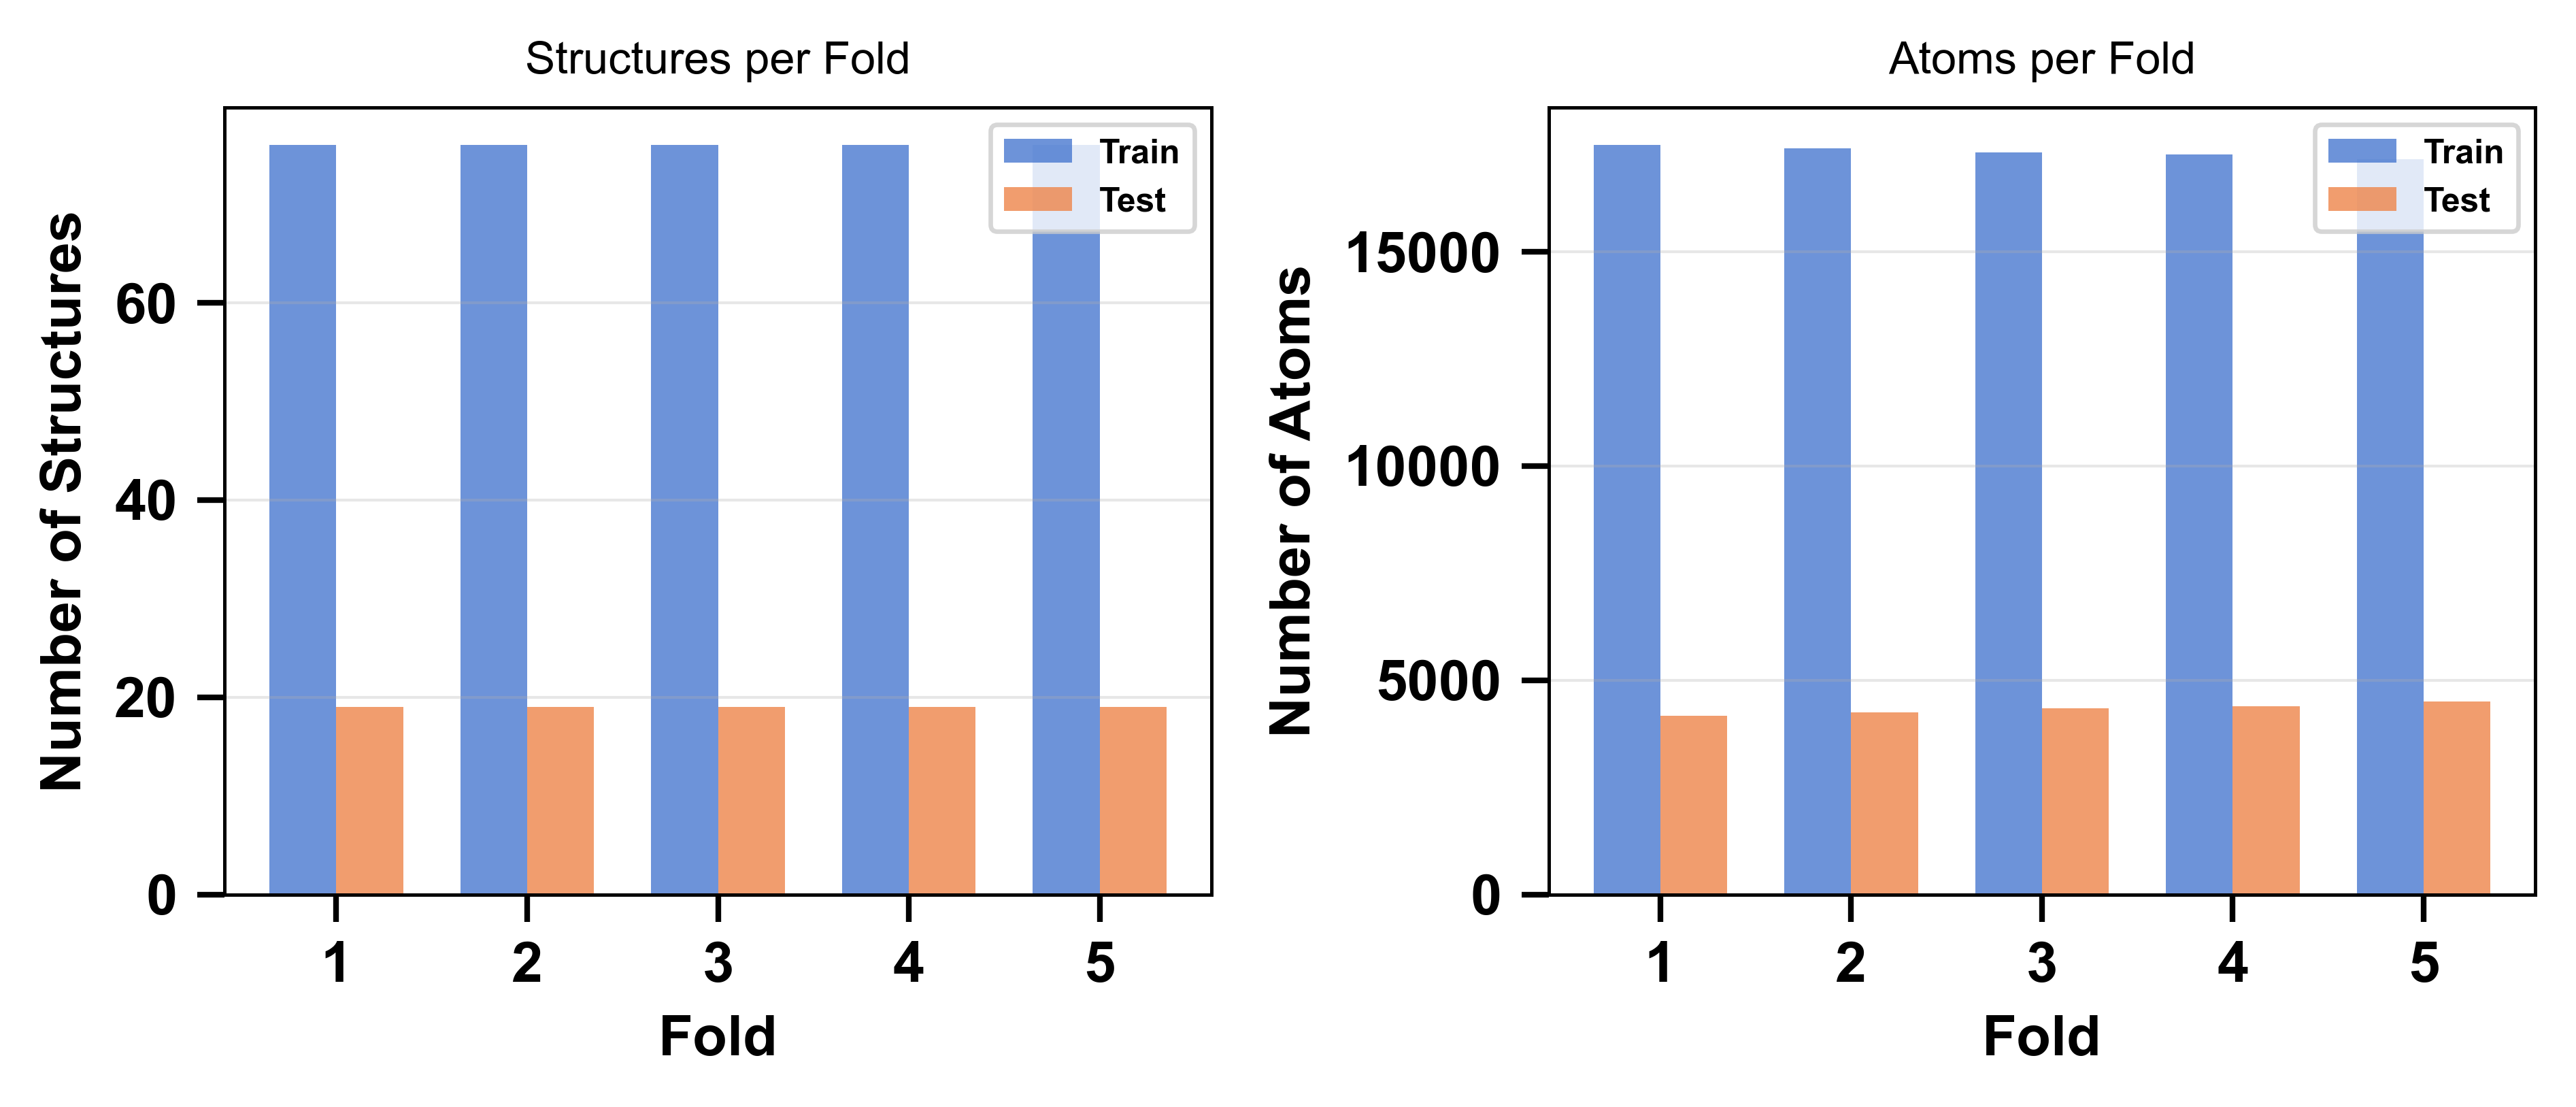


已保存: figures/eda_plots/cv_fold_distribution.png


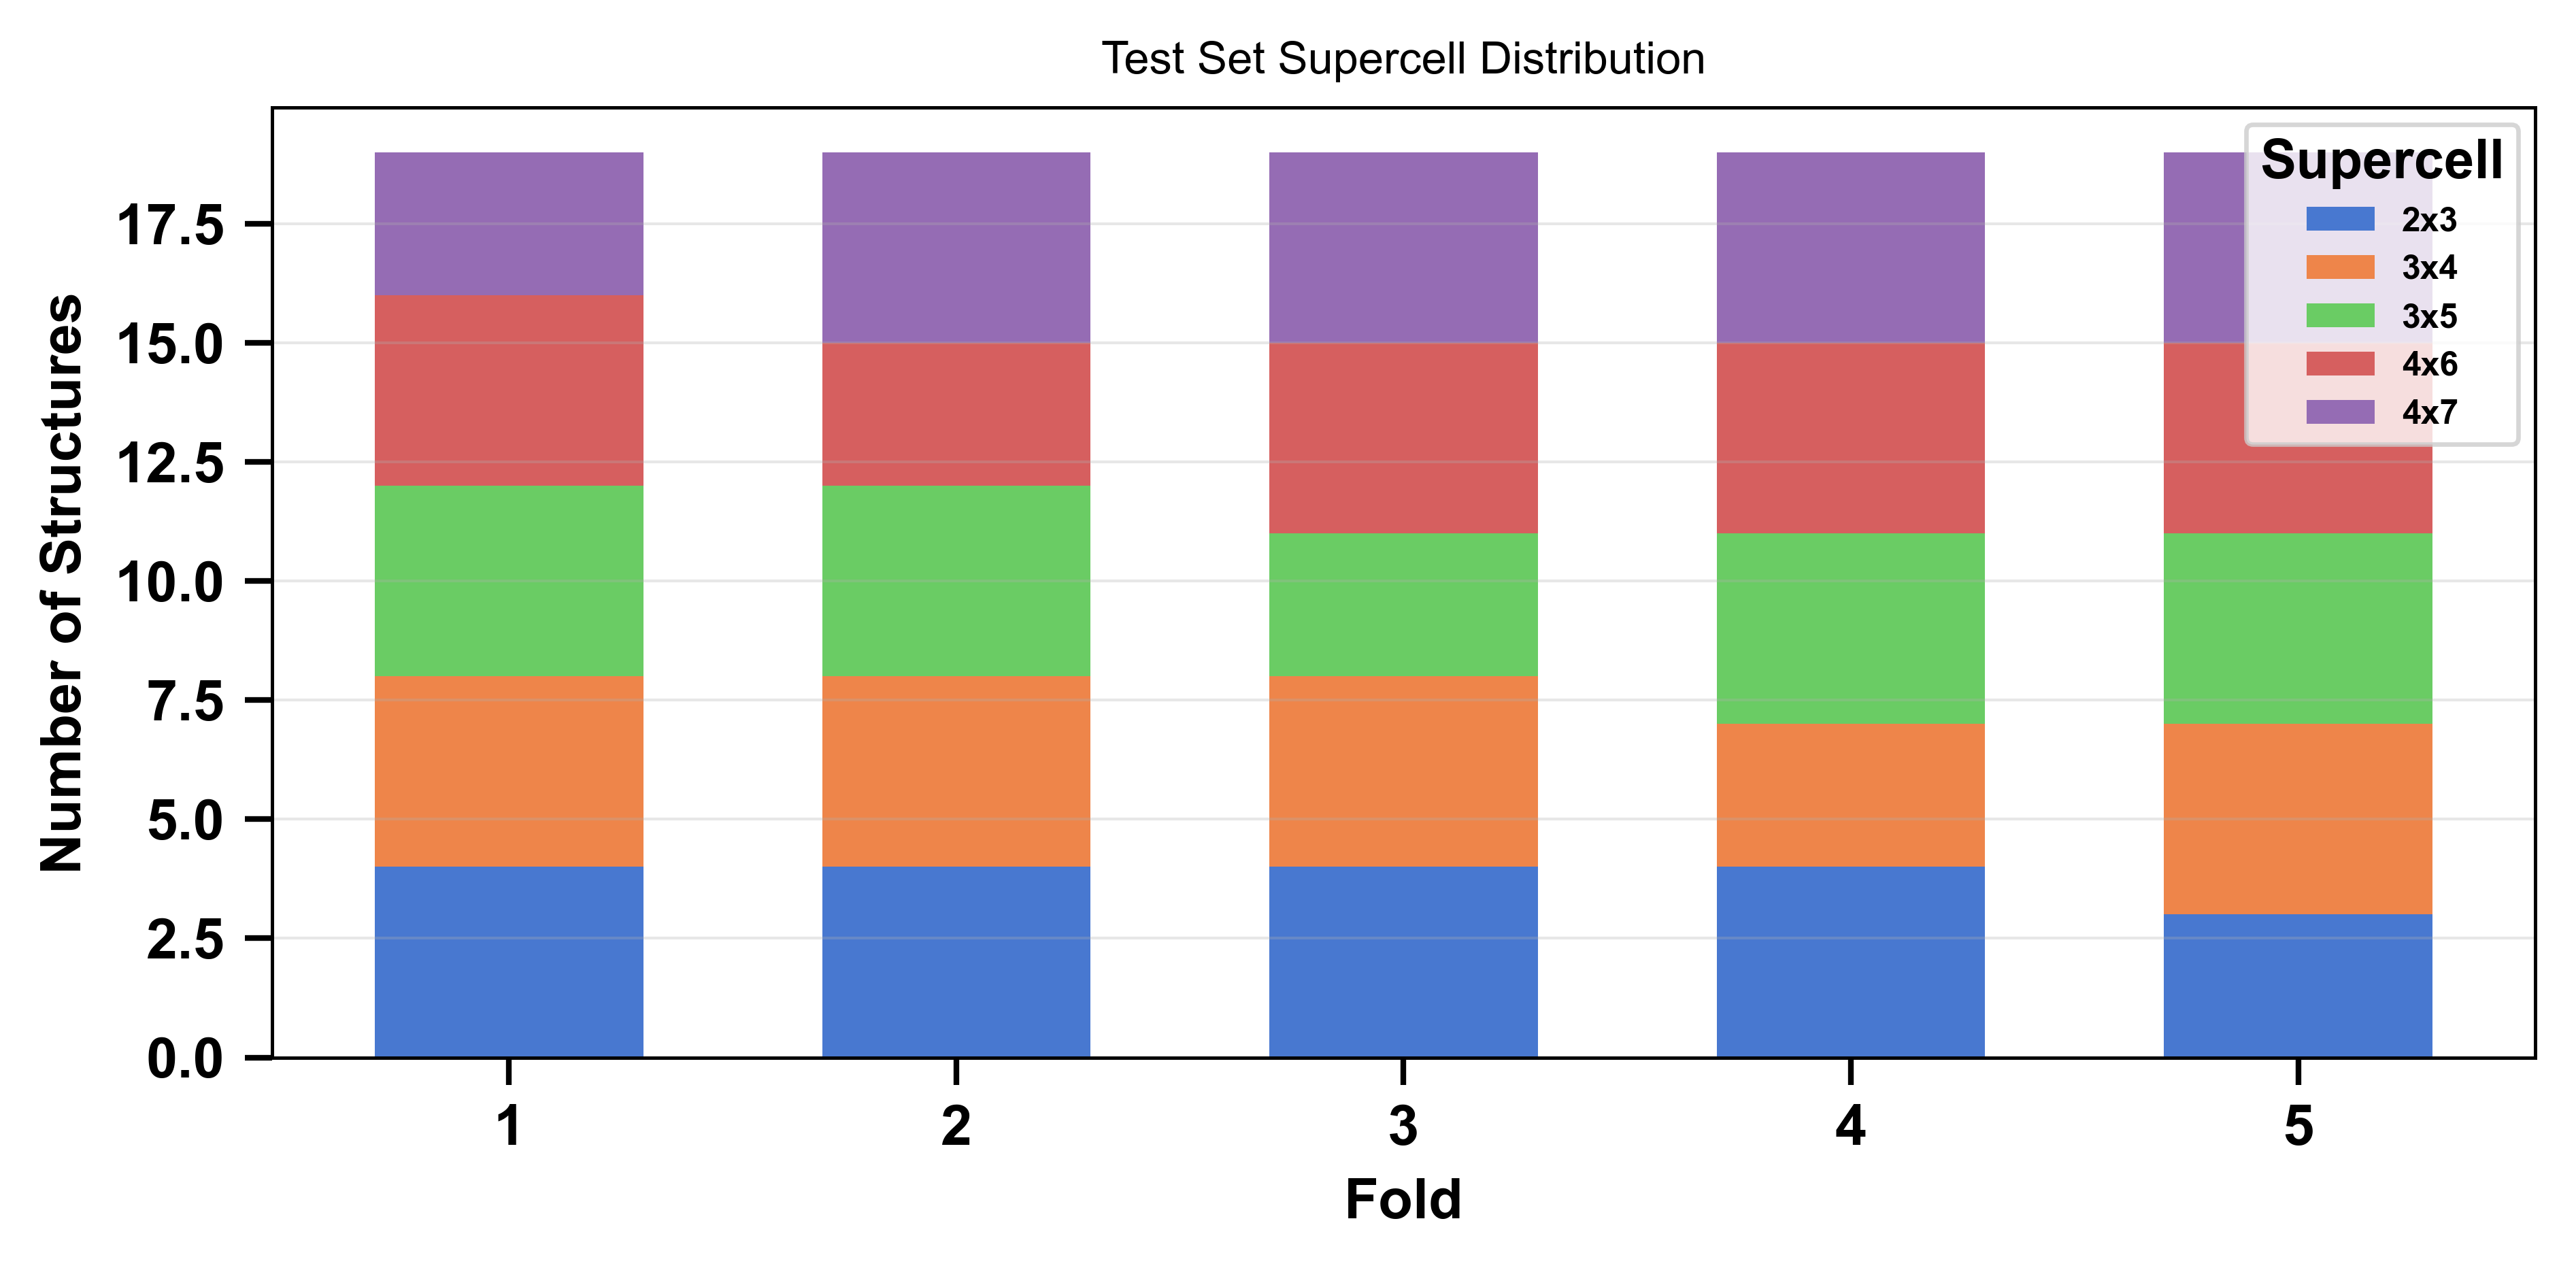

已保存: figures/eda_plots/cv_supercell_distribution.png
已保存: data/cv_setup.pkl
已保存: data/cv_setup_inner.pkl
已保存: data/structure_info.csv
已保存: data/cv_summary.json
已保存: data/cv_setup_report.txt

特征数量: 15
结构数量: 95，原子数量: 21665
外层折数: 5，内层折数: 5

保存文件:
  data/cv_setup.pkl
  data/cv_setup_inner.pkl
  data/cv_summary.json
  data/cv_setup_report.txt
  data/structure_info.csv

数据划分设置完成


In [1]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# 数据划分与交叉验证设置（删除冗余特征版本）
# 功能: 读取 feature_selection.json，使用筛选后的特征，
#       设置结构级别5-5嵌套交叉验证，保存CV设置供后续使用
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 绘图参数设置
# ============================================================

sns.set_context("paper")
sns.set_palette('muted')

ss = 10
sss = 8
ssss = 6

matplotlib.rcParams['figure.figsize'] = (3.2, 2.8)
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams["axes.labelweight"] = "bold"
matplotlib.rcParams['axes.titlesize'] = sss
matplotlib.rcParams['legend.fontsize'] = ss
matplotlib.rcParams['axes.labelsize'] = ss
matplotlib.rcParams['xtick.labelsize'] = ss
matplotlib.rcParams['ytick.labelsize'] = ss
matplotlib.rcParams['axes.linewidth'] = 0.6
matplotlib.rcParams['lines.linewidth'] = 1.0

ref_line_size = 0.8

# ============================================================
# 加载数据与特征配置
# ============================================================

df = pd.read_csv('data/full_dataset.csv')
print(f"数据形状: {df.shape}")

if Path('data/feature_selection.json').exists():
    with open('data/feature_selection.json', 'r', encoding='utf-8') as f:
        feature_selection = json.load(f)

    feature_cols = feature_selection['selected_features']
    print(f"\n读取 feature_selection.json")
    print(f"原始特征数: {feature_selection['n_original']}")
    print(f"筛选后特征数: {feature_selection['n_selected']}")
    print(f"删除特征数: {feature_selection['n_removed']}")
    if feature_selection['n_removed'] > 0:
        print(f"删除的特征: {feature_selection['removed_features']}")
else:
    # 未检测到筛选结果时回退到全特征（与原始数据划分代码保持一致）
    print("\n未检测到 feature_selection.json，使用全部特征")
    feature_cols = [
        'T_O', 'T_C', 'T_Ti1', 'T_Ti2',
        'Rad', 'EN',
        'Layer', 'D_E', 'D_C', 'D_M1', 'D_M2',
        'N_O', 'N_C', 'N_Ti1', 'N_Ti2', 'M_Inf',
        'SC_a', 'SC_b', 'H_A', 'H_P', 'AR', 'H_Dens', 'Sides', 'Del'
    ]

target_col = 'Q_M'

missing_cols = [col for col in feature_cols + [target_col] if col not in df.columns]
if missing_cols:
    raise ValueError(f"数据集中缺少以下列: {missing_cols}")

N_OUTER_FOLDS = 5
N_INNER_FOLDS = 5
RANDOM_STATE = 42

print(f"\n使用特征数: {len(feature_cols)}")
print(f"目标变量: {target_col}")
print(f"结构数量: {df['structure_id'].nunique()}")
print(f"原子数量: {len(df)}")
print(f"外层折数: {N_OUTER_FOLDS}，内层折数: {N_INNER_FOLDS}，随机种子: {RANDOM_STATE}")

# ============================================================
# 准备结构级别数据
# ============================================================

structure_info = df.groupby('structure_id').agg(
    supercell=('supercell', 'first'),
    n_atoms=('Q_M', 'count')
).reset_index()

supercell_map = {sc: i for i, sc in enumerate(['2x3', '3x4', '3x5', '4x6', '4x7'])}
structure_info['supercell_label'] = structure_info['supercell'].map(supercell_map)

print(f"\n总结构数: {len(structure_info)}")
supercell_counts = structure_info['supercell'].value_counts().sort_index()
for sc, count in supercell_counts.items():
    print(f"  {sc}: {count} 个结构")

# ============================================================
# 设置外层5折交叉验证
# ============================================================

outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

outer_folds = []
for fold_idx, (train_structures_idx, test_structures_idx) in enumerate(
        outer_cv.split(structure_info, structure_info['supercell_label'])):

    train_structures = structure_info.iloc[train_structures_idx]['structure_id'].tolist()
    test_structures = structure_info.iloc[test_structures_idx]['structure_id'].tolist()

    train_atoms_idx = df[df['structure_id'].isin(train_structures)].index.tolist()
    test_atoms_idx = df[df['structure_id'].isin(test_structures)].index.tolist()

    fold_info = {
        'fold': fold_idx + 1,
        'train_structures': train_structures,
        'test_structures': test_structures,
        'train_atoms_idx': train_atoms_idx,
        'test_atoms_idx': test_atoms_idx,
        'n_train_structures': len(train_structures),
        'n_test_structures': len(test_structures),
        'n_train_atoms': len(train_atoms_idx),
        'n_test_atoms': len(test_atoms_idx)
    }
    outer_folds.append(fold_info)

    train_dist = structure_info.iloc[train_structures_idx]['supercell'].value_counts().sort_index()
    test_dist = structure_info.iloc[test_structures_idx]['supercell'].value_counts().sort_index()
    print(f"\n外层折叠 {fold_idx + 1}: 训练 {len(train_structures)} 结构 / {len(train_atoms_idx)} 原子，"
          f"测试 {len(test_structures)} 结构 / {len(test_atoms_idx)} 原子")
    print(f"  训练超胞分布: {dict(train_dist)}")
    print(f"  测试超胞分布: {dict(test_dist)}")

# ============================================================
# 设置内层5折交叉验证
# ============================================================

inner_folds_all = []
for outer_fold_idx, outer_fold in enumerate(outer_folds):
    train_structures = outer_fold['train_structures']
    train_structure_info = structure_info[structure_info['structure_id'].isin(train_structures)]

    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    inner_folds = []

    for inner_fold_idx, (inner_train_idx, inner_val_idx) in enumerate(
            inner_cv.split(train_structure_info, train_structure_info['supercell_label'])):

        inner_train_structures = train_structure_info.iloc[inner_train_idx]['structure_id'].tolist()
        inner_val_structures = train_structure_info.iloc[inner_val_idx]['structure_id'].tolist()

        inner_folds.append({
            'inner_fold': inner_fold_idx + 1,
            'inner_train_structures': inner_train_structures,
            'inner_val_structures': inner_val_structures,
            'inner_train_atoms_idx': df[df['structure_id'].isin(inner_train_structures)].index.tolist(),
            'inner_val_atoms_idx': df[df['structure_id'].isin(inner_val_structures)].index.tolist(),
            'n_inner_train_structures': len(inner_train_structures),
            'n_inner_val_structures': len(inner_val_structures),
        })

    inner_folds_all.append({'outer_fold': outer_fold_idx + 1, 'inner_folds': inner_folds})
    print(f"外层折叠 {outer_fold_idx + 1}: 生成 {N_INNER_FOLDS} 个内层折叠")

# ============================================================
# 验证划分的合理性
# ============================================================

all_test_structures = []
for fold in outer_folds:
    all_test_structures.extend(fold['test_structures'])

if len(all_test_structures) == len(set(all_test_structures)):
    print("\n测试集结构互不重叠: 通过")
else:
    print("\n警告: 发现重叠的测试集结构")

if set(all_test_structures) == set(structure_info['structure_id']):
    print("所有结构均被覆盖: 通过")
else:
    missing = set(structure_info['structure_id']) - set(all_test_structures)
    print(f"警告: {len(missing)} 个结构未被覆盖")

print("\n各折超胞分布最大差异:")
for fold in outer_folds:
    train_df = structure_info[structure_info['structure_id'].isin(fold['train_structures'])]
    test_df = structure_info[structure_info['structure_id'].isin(fold['test_structures'])]
    train_dist = train_df['supercell'].value_counts(normalize=True).sort_index()
    test_dist = test_df['supercell'].value_counts(normalize=True).sort_index()
    max_diff = max(abs(train_dist - test_dist))
    status = "通过" if max_diff < 0.15 else "偏差较大"
    print(f"  折叠 {fold['fold']}: {max_diff:.3f} ({status})")

summary_stats = {
    'train_structures_per_fold': [f['n_train_structures'] for f in outer_folds],
    'test_structures_per_fold': [f['n_test_structures'] for f in outer_folds],
    'train_atoms_per_fold': [f['n_train_atoms'] for f in outer_folds],
    'test_atoms_per_fold': [f['n_test_atoms'] for f in outer_folds]
}

print(f"\n训练结构数（每折）: {summary_stats['train_structures_per_fold']}")
print(f"  均值 ± 标准差: {np.mean(summary_stats['train_structures_per_fold']):.1f} "
      f"± {np.std(summary_stats['train_structures_per_fold']):.2f}")
print(f"测试结构数（每折）: {summary_stats['test_structures_per_fold']}")
print(f"  均值 ± 标准差: {np.mean(summary_stats['test_structures_per_fold']):.1f} "
      f"± {np.std(summary_stats['test_structures_per_fold']):.2f}")

# ============================================================
# 可视化交叉验证划分
# ============================================================

Path('figures/eda_plots').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))

folds_num = [f['fold'] for f in outer_folds]
x = np.arange(len(folds_num))
width = 0.35

axes[0].bar(x - width / 2, summary_stats['train_structures_per_fold'],
            width, label='Train', alpha=0.8)
axes[0].bar(x + width / 2, summary_stats['test_structures_per_fold'],
            width, label='Test', alpha=0.8)
axes[0].set_xlabel('Fold', fontsize=ss)
axes[0].set_ylabel('Number of Structures', fontsize=ss)
axes[0].set_title('Structures per Fold', fontsize=sss)
axes[0].set_xticks(x)
axes[0].set_xticklabels(folds_num)
axes[0].legend(fontsize=ssss, frameon=True)
axes[0].grid(axis='y', alpha=0.3, linewidth=0.5)

axes[1].bar(x - width / 2, summary_stats['train_atoms_per_fold'],
            width, label='Train', alpha=0.8)
axes[1].bar(x + width / 2, summary_stats['test_atoms_per_fold'],
            width, label='Test', alpha=0.8)
axes[1].set_xlabel('Fold', fontsize=ss)
axes[1].set_ylabel('Number of Atoms', fontsize=ss)
axes[1].set_title('Atoms per Fold', fontsize=sss)
axes[1].set_xticks(x)
axes[1].set_xticklabels(folds_num)
axes[1].legend(fontsize=ssss, frameon=True)
axes[1].grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('figures/eda_plots/cv_fold_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print("\n已保存: figures/eda_plots/cv_fold_distribution.png")

# 超胞分布堆叠图
fig, ax = plt.subplots(figsize=(6.4, 3.2))

supercell_types = ['2x3', '3x4', '3x5', '4x6', '4x7']
fold_supercell_dist = {sc: [] for sc in supercell_types}

for fold in outer_folds:
    test_structures_df = structure_info[structure_info['structure_id'].isin(fold['test_structures'])]
    test_dist = test_structures_df['supercell'].value_counts()
    for sc in supercell_types:
        fold_supercell_dist[sc].append(test_dist.get(sc, 0))

bottom = np.zeros(N_OUTER_FOLDS)
for sc in supercell_types:
    ax.bar(folds_num, fold_supercell_dist[sc], bottom=bottom, label=sc, width=0.6)
    bottom += np.array(fold_supercell_dist[sc])

ax.set_xlabel('Fold', fontsize=ss)
ax.set_ylabel('Number of Structures', fontsize=ss)
ax.set_title('Test Set Supercell Distribution', fontsize=sss)
ax.legend(title='Supercell', fontsize=ssss, frameon=True, loc='upper right')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('figures/eda_plots/cv_supercell_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print("已保存: figures/eda_plots/cv_supercell_distribution.png")

# ============================================================
# 保存CV设置
# ============================================================

Path('data').mkdir(exist_ok=True)

scaler_config = {
    'scaler_type': 'StandardScaler',
    'feature_cols': feature_cols,
    'description': '在每个CV折叠中，标准化器在训练集上拟合，应用于测试集'
}

cv_setup = {
    'n_outer_folds': N_OUTER_FOLDS,
    'n_inner_folds': N_INNER_FOLDS,
    'random_state': RANDOM_STATE,
    'feature_cols': feature_cols,
    'target_col': target_col,
    'n_structures': len(structure_info),
    'n_atoms': len(df),
    'outer_folds': outer_folds,
    'scaler_config': scaler_config
}

with open('data/cv_setup.pkl', 'wb') as f:
    pickle.dump(cv_setup, f)
print("已保存: data/cv_setup.pkl")

with open('data/cv_setup_inner.pkl', 'wb') as f:
    pickle.dump(inner_folds_all, f)
print("已保存: data/cv_setup_inner.pkl")

structure_info.to_csv('data/structure_info.csv', index=False)
print("已保存: data/structure_info.csv")

cv_summary = {
    'n_outer_folds': N_OUTER_FOLDS,
    'n_inner_folds': N_INNER_FOLDS,
    'random_state': RANDOM_STATE,
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'target': target_col,
    'n_structures': len(structure_info),
    'n_atoms': len(df),
    'outer_folds_summary': [
        {
            'fold': f['fold'],
            'n_train_structures': f['n_train_structures'],
            'n_test_structures': f['n_test_structures'],
            'n_train_atoms': f['n_train_atoms'],
            'n_test_atoms': f['n_test_atoms']
        }
        for f in outer_folds
    ],
    'statistics': {
        'mean_train_structures': float(np.mean(summary_stats['train_structures_per_fold'])),
        'std_train_structures': float(np.std(summary_stats['train_structures_per_fold'])),
        'mean_test_structures': float(np.mean(summary_stats['test_structures_per_fold'])),
        'std_test_structures': float(np.std(summary_stats['test_structures_per_fold'])),
        'mean_train_atoms': float(np.mean(summary_stats['train_atoms_per_fold'])),
        'mean_test_atoms': float(np.mean(summary_stats['test_atoms_per_fold']))
    }
}

with open('data/cv_summary.json', 'w', encoding='utf-8') as f:
    json.dump(cv_summary, f, indent=4, ensure_ascii=False)
print("已保存: data/cv_summary.json")

# 文本报告
report_file = 'data/cv_setup_report.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write("交叉验证设置报告（删除冗余特征版本）\n")
    f.write("=" * 70 + "\n\n")
    f.write("1. 基本配置\n")
    f.write("-" * 70 + "\n")
    f.write(f"外层折数: {N_OUTER_FOLDS}\n")
    f.write(f"内层折数: {N_INNER_FOLDS}\n")
    f.write(f"随机种子: {RANDOM_STATE}\n")
    f.write(f"总结构数: {len(structure_info)}\n")
    f.write(f"总原子数: {len(df)}\n")
    f.write(f"特征数量: {len(feature_cols)}\n")
    f.write(f"目标变量: {target_col}\n\n")
    f.write("使用的特征:\n")
    for i, feat in enumerate(feature_cols, 1):
        f.write(f"  {i:2d}. {feat}\n")
    f.write("\n")
    f.write("2. 外层交叉验证划分\n")
    f.write("-" * 70 + "\n")
    for fold in outer_folds:
        f.write(f"折叠 {fold['fold']}: 训练 {fold['n_train_structures']} 结构 / "
                f"{fold['n_train_atoms']} 原子，测试 {fold['n_test_structures']} 结构 / "
                f"{fold['n_test_atoms']} 原子\n")
    f.write("\n")
    f.write("3. 划分统计\n")
    f.write("-" * 70 + "\n")
    f.write(f"平均训练结构数: {np.mean(summary_stats['train_structures_per_fold']):.1f} "
            f"± {np.std(summary_stats['train_structures_per_fold']):.2f}\n")
    f.write(f"平均测试结构数: {np.mean(summary_stats['test_structures_per_fold']):.1f} "
            f"± {np.std(summary_stats['test_structures_per_fold']):.2f}\n")
    f.write(f"平均训练原子数: {np.mean(summary_stats['train_atoms_per_fold']):.0f}\n")
    f.write(f"平均测试原子数: {np.mean(summary_stats['test_atoms_per_fold']):.0f}\n\n")
    f.write("4. 数据标准化\n")
    f.write("-" * 70 + "\n")
    f.write("标准化方法: StandardScaler\n")
    f.write(f"标准化特征: {len(feature_cols)} 个\n")
    f.write("说明: 在每个CV折叠中，标准化器在训练集上拟合，应用于测试集\n")

print(f"已保存: {report_file}")

# ============================================================
# 完成摘要
# ============================================================

print(f"\n特征数量: {len(feature_cols)}")
print(f"结构数量: {len(structure_info)}，原子数量: {len(df)}")
print(f"外层折数: {N_OUTER_FOLDS}，内层折数: {N_INNER_FOLDS}")
print(f"\n保存文件:")
print(f"  data/cv_setup.pkl")
print(f"  data/cv_setup_inner.pkl")
print(f"  data/cv_summary.json")
print(f"  data/cv_setup_report.txt")
print(f"  data/structure_info.csv")
print("\n数据划分设置完成")